********************************************************


************

*****

In [13]:
from joblib import load

# List of all data object names
data_object_names = [
    'X_test',
    'X_train',
    'X_train_scaled_df',
    'X_unseen',
    'X_unseen_scaled_df',
    'X_val',
    'X_val_scaled_df',
    'y_train',
    'y_unseen',
    'y_val'
]

# Load each object using joblib and store them in a dictionary
loaded_data_objects = {name: load(f'{name}.joblib') for name in data_object_names}

# Access each loaded object
X_test = loaded_data_objects['X_test']
X_train = loaded_data_objects['X_train']
X_train_scaled_df = loaded_data_objects['X_train_scaled_df']
X_unseen = loaded_data_objects['X_unseen']
X_unseen_scaled_df = loaded_data_objects['X_unseen_scaled_df']
X_val = loaded_data_objects['X_val']
X_val_scaled_df = loaded_data_objects['X_val_scaled_df']
y_train = loaded_data_objects['y_train']
y_unseen = loaded_data_objects['y_unseen']
y_val = loaded_data_objects['y_val']


In [14]:
# Select the features based on the correlation threshold
selected_features = ['amt', 'category_WOE']

# Create a new DataFrame with only the selected features and the target variable
X_unseen_scaled_df = X_unseen_scaled_df[selected_features]
X_train_scaled_df = X_train_scaled_df[selected_features]
X_val_scaled_df = X_val_scaled_df[selected_features]

Estimate for scale_pos_weight: 171.758
Validation Accuracy: 0.9208360860970224
Validation Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96    386751
           1       0.07      0.97      0.12      2252

    accuracy                           0.92    389003
   macro avg       0.53      0.95      0.54    389003
weighted avg       0.99      0.92      0.95    389003

Validation Confusion Matrix:
 [[356019  30732]
 [    63   2189]]
Validation ROC AUC Score: 0.9799966313618935
Validation PR AUC Score: 0.22308867373626212


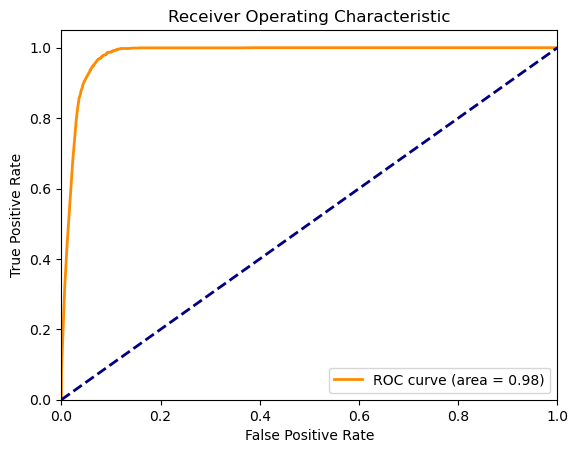

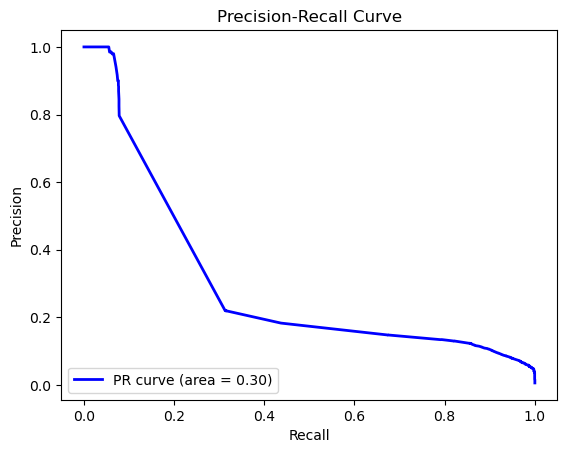

In [15]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
from collections import Counter

# Calculate scale_pos_weight
counter = Counter(y_train)
scale_pos_weight = counter[0] / counter[1]
print('Estimate for scale_pos_weight: %.3f' % scale_pos_weight)

# Define the initial XGBoost model
xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42)

# Train the model on the training data
xgb_model.fit(X_train_scaled_df, y_train)

# Make predictions on the validation data
y_val_pred = xgb_model.predict(X_val_scaled_df)
y_val_pred_proba = xgb_model.predict_proba(X_val_scaled_df)[:, 1]

# Evaluate the model on the validation data
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report:\n", classification_report(y_val, y_val_pred))
print("Validation Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Validation ROC AUC Score:", roc_auc_score(y_val, y_val_pred_proba))
print("Validation PR AUC Score:", average_precision_score(y_val, y_val_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

Unseen Data Accuracy: 0.9202798536670511
Unseen Data Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96    553574
           1       0.04      0.97      0.09      2145

    accuracy                           0.92    555719
   macro avg       0.52      0.94      0.52    555719
weighted avg       1.00      0.92      0.95    555719

Unseen Data Confusion Matrix:
 [[509340  44234]
 [    68   2077]]
Unseen Data ROC AUC Score: 0.9790472541376667
Unseen Data PR AUC Score: 0.17666167719112633


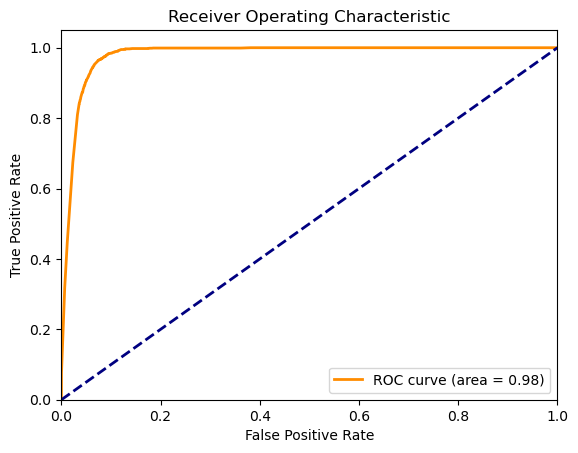

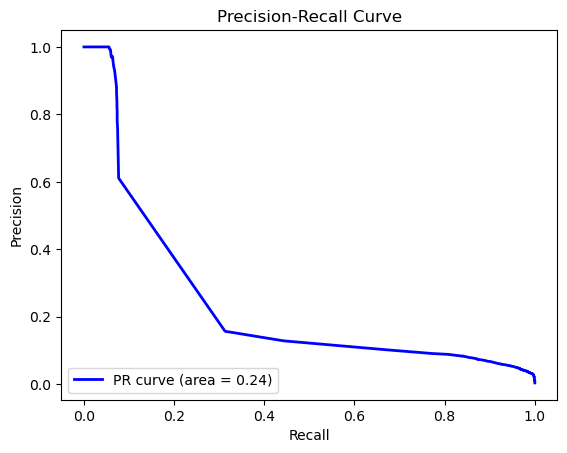

In [16]:
# Make predictions on the unseen data with the best estimator
y_unseen_pred = xgb_model.predict(X_unseen_scaled_df)
y_unseen_pred_proba = xgb_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Evaluate the model on the unseen data
print("Unseen Data Accuracy:", accuracy_score(y_unseen, y_unseen_pred))
print("Unseen Data Classification Report:\n", classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:\n", confusion_matrix(y_unseen, y_unseen_pred))
print("Unseen Data ROC AUC Score:", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score:", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

In [19]:
%%time
from sklearn.model_selection import cross_validate, StratifiedKFold

# Initialize StratifiedKFold
strat_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
from skopt import BayesSearchCV
from skopt.space import Real, Integer

# Define the parameter grid
param_grid = {
    'scale_pos_weight': Integer(1, 1000),
    'n_estimators': Integer(50, 200),
    'max_depth': Integer(1, 30),
    'learning_rate': Real(0.01, 0.2, prior='log-uniform')
}

# Initialize the Bayesian Search CV
bayes_search = BayesSearchCV(
    estimator=xgb_model,
    search_spaces=param_grid,
    cv=strat_k_fold,
    scoring='roc_auc',
    n_jobs=-1,
    n_iter=32,  # Number of parameter settings that are sampled
    random_state=42,
    refit=True
)
# Perform the search with threading backend
import joblib
with joblib.parallel_backend('threading'):
    bayes_search.fit(X_train_scaled_df, y_train)
# Perform the search


# Best parameters and score
print("Best Parameters:", bayes_search.best_params_)
print("Best Cross-Validation ROC AUC Score:", bayes_search.best_score_)

Best Parameters: OrderedDict([('learning_rate', 0.15835004552726092), ('max_depth', 10), ('n_estimators', 91), ('scale_pos_weight', 1)])
Best Cross-Validation ROC AUC Score: 0.9797600182665762
CPU times: total: 53min 4s
Wall time: 2min 24s


Best Threshold: 0.16592066
Unseen Data Accuracy (Tuned Threshold): 0.9908298978440543
Unseen Data Classification Report (Tuned Threshold):
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.16      0.32      0.21      2145

    accuracy                           0.99    555719
   macro avg       0.58      0.65      0.60    555719
weighted avg       0.99      0.99      0.99    555719

Unseen Data Confusion Matrix (Tuned Threshold):
 [[549946   3628]
 [  1468    677]]
Unseen Data ROC AUC Score (Tuned Threshold): 0.9787800976073908
Unseen Data PR AUC Score (Tuned Threshold): 0.17724412295418493


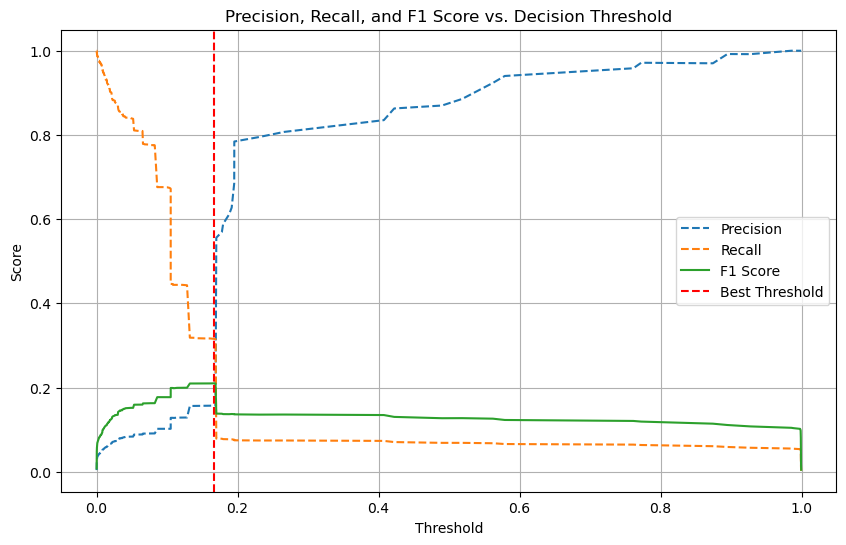

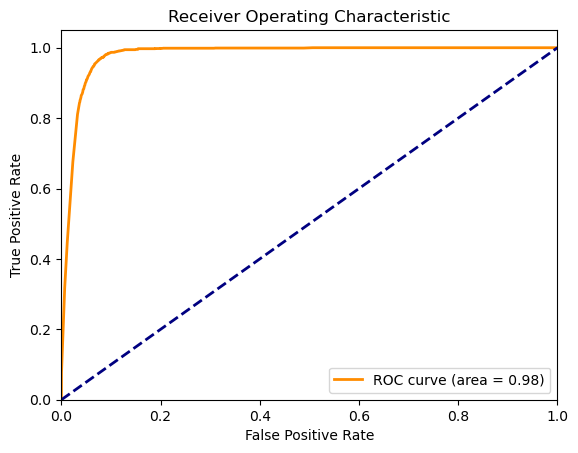

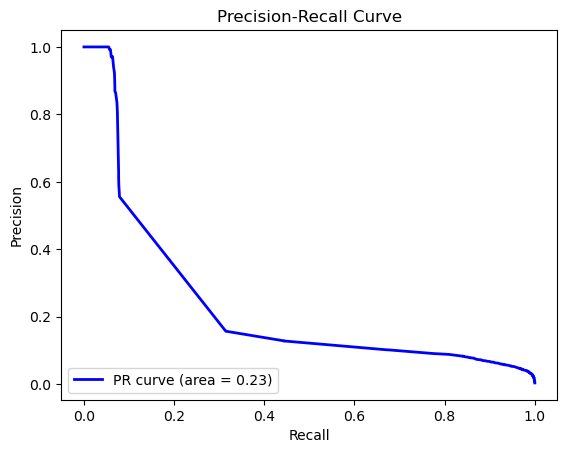

In [21]:
from sklearn.metrics import precision_recall_curve, accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Make predictions on the unseen data
y_unseen_pred_proba = bayes_search.best_estimator_.predict_proba(X_unseen_scaled_df)[:, 1]

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_unseen, y_unseen_pred_proba)

# Calculate F1 scores for all thresholds
f1_scores = 2 * (precision * recall) / (precision + recall)

# Find the threshold that maximizes the F1-score
best_threshold = thresholds[np.argmax(f1_scores)]
print("Best Threshold:", best_threshold)

# Apply the best threshold to the predictions
y_unseen_pred_tuned = (y_unseen_pred_proba >= best_threshold).astype(int)

# Evaluate the tuned threshold predictions
print("Unseen Data Accuracy (Tuned Threshold):", accuracy_score(y_unseen, y_unseen_pred_tuned))
print("Unseen Data Classification Report (Tuned Threshold):\n", classification_report(y_unseen, y_unseen_pred_tuned))
print("Unseen Data Confusion Matrix (Tuned Threshold):\n", confusion_matrix(y_unseen, y_unseen_pred_tuned))
print("Unseen Data ROC AUC Score (Tuned Threshold):", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score (Tuned Threshold):", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot Precision-Recall curve and F1 score
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label="Precision", linestyle='--')
plt.plot(thresholds, recall[:-1], label="Recall", linestyle='--')
plt.plot(thresholds, f1_scores[:-1], label="F1 Score")
plt.axvline(x=best_threshold, color='r', linestyle='--', label="Best Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 Score vs. Decision Threshold")
plt.legend(loc="best")
plt.grid()
plt.show()

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()


In [2]:
X_unseen

,amt,city_pop,trans_hour,trans_month,timedelta_last_trans,cust_age,distance_from_prev_merch,state_WOE,job_WOE,category_WOE,trans_dayofweek_WOE,gender_M
0,124.66,1645,13,6,1274.0,34.0,16843.410189,0.020036,0.610247,-1.247672,-0.182241,0.0
1,78.52,1645,16,6,199.0,34.0,16697.254733,0.020036,0.610247,-0.651283,-0.182241,0.0
2,65.25,1645,7,6,932.0,34.0,16969.485038,0.020036,0.610247,-0.166190,-0.193172,0.0
3,87.74,1645,15,6,453.0,34.0,16882.690815,0.020036,0.610247,-0.998260,-0.193172,0.0
4,148.02,1645,12,6,1256.0,34.0,16855.209244,0.020036,0.610247,-0.893267,0.013032,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
555714,66.11,532,2,12,134.0,65.0,14448.692561,-0.035181,0.371500,-0.166190,0.119141,1.0
555715,4.58,532,5,12,183.0,65.0,14393.529439,-0.035181,0.371500,0.933445,0.119141,1.0
555716,95.96,532,11,12,362.0,65.0,14538.772243,-0.035181,0.371500,-0.166190,0.119141,1.0
555717,149.48,532,11,12,1.0,65.0,14615.208190,-0.035181,0.371500,0.897015,0.119141,1.0


In [3]:
X_unseen_scaled_df

,amt,city_pop,trans_hour,trans_month,timedelta_last_trans,cust_age,distance_from_prev_merch,state_WOE,job_WOE,category_WOE,trans_dayofweek_WOE,gender_M
0,0.642765,0.032647,0.565217,0.454545,0.831321,0.257669,0.841275,0.148779,0.347469,0.022581,0.028068,0.0
1,0.402937,0.032647,0.695652,0.454545,0.129853,0.257669,0.817953,0.148779,0.347469,0.270028,0.028068,0.0
2,0.333961,0.032647,0.304348,0.454545,0.608157,0.257669,0.861393,0.148779,0.347469,0.471296,0.000000,0.0
3,0.450861,0.032647,0.652174,0.454545,0.295595,0.257669,0.847543,0.148779,0.347469,0.126064,0.000000,0.0
4,0.764187,0.032647,0.521739,0.454545,0.819576,0.257669,0.843158,0.148779,0.347469,0.169627,0.529474,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
555714,0.338432,0.010245,0.086957,1.000000,0.087439,0.638037,0.459149,0.142256,0.325755,0.471296,0.801931,1.0
555715,0.018608,0.010245,0.217391,1.000000,0.119413,0.638037,0.450347,0.142256,0.325755,0.927544,0.801931,1.0
555716,0.493587,0.010245,0.478261,1.000000,0.236215,0.638037,0.473523,0.142256,0.325755,0.471296,0.801931,1.0
555717,0.771776,0.010245,0.478261,1.000000,0.000653,0.638037,0.485720,0.142256,0.325755,0.912429,0.801931,1.0


<Axes: >

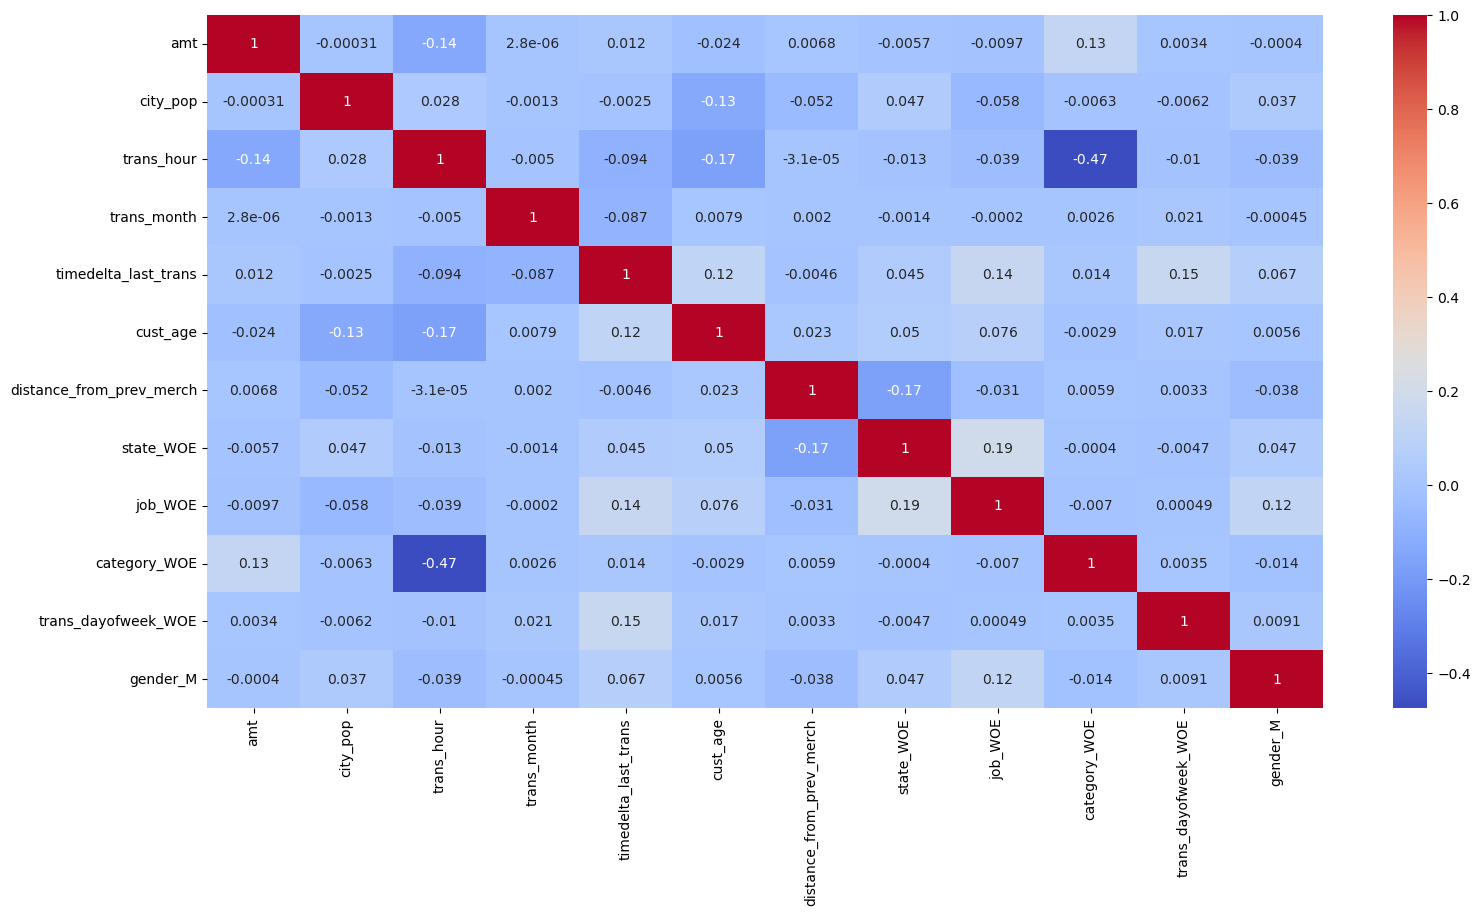

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
correlation=X_unseen_scaled_df.corr()
# Create a heatmap for the correlation matrix
fig = plt.figure(figsize=(18, 9))
sns.heatmap(correlation, cmap='coolwarm', annot=True)

In [8]:
y_unseen

0         0
1         0
2         0
3         0
4         0
         ..
555714    0
555715    0
555716    0
555717    0
555718    0
Name: is_fraud, Length: 555719, dtype: int64

In [9]:
df = X_unseen_scaled_df.copy()
df['is_fraud'] = y_unseen.values
df

,amt,city_pop,trans_hour,trans_month,timedelta_last_trans,cust_age,distance_from_prev_merch,state_WOE,job_WOE,category_WOE,trans_dayofweek_WOE,gender_M,is_fraud
0,0.642765,0.032647,0.565217,0.454545,0.831321,0.257669,0.841275,0.148779,0.347469,0.022581,0.028068,0.0,0
1,0.402937,0.032647,0.695652,0.454545,0.129853,0.257669,0.817953,0.148779,0.347469,0.270028,0.028068,0.0,0
2,0.333961,0.032647,0.304348,0.454545,0.608157,0.257669,0.861393,0.148779,0.347469,0.471296,0.000000,0.0,0
3,0.450861,0.032647,0.652174,0.454545,0.295595,0.257669,0.847543,0.148779,0.347469,0.126064,0.000000,0.0,0
4,0.764187,0.032647,0.521739,0.454545,0.819576,0.257669,0.843158,0.148779,0.347469,0.169627,0.529474,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,0.338432,0.010245,0.086957,1.000000,0.087439,0.638037,0.459149,0.142256,0.325755,0.471296,0.801931,1.0,0
555715,0.018608,0.010245,0.217391,1.000000,0.119413,0.638037,0.450347,0.142256,0.325755,0.927544,0.801931,1.0,0
555716,0.493587,0.010245,0.478261,1.000000,0.236215,0.638037,0.473523,0.142256,0.325755,0.471296,0.801931,1.0,0
555717,0.771776,0.010245,0.478261,1.000000,0.000653,0.638037,0.485720,0.142256,0.325755,0.912429,0.801931,1.0,0


<Axes: >

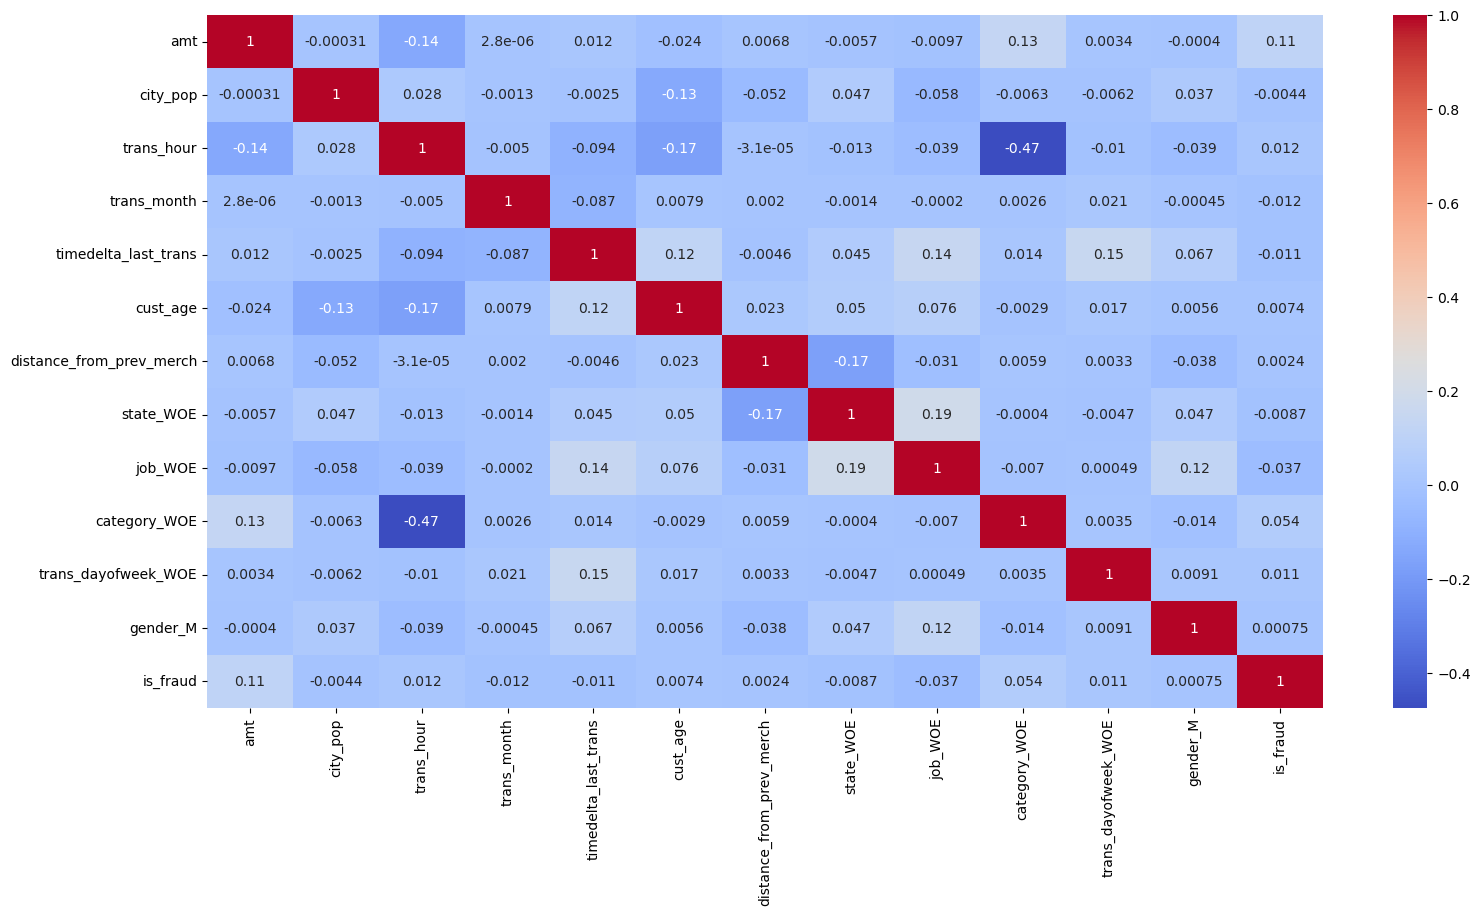

In [10]:
# Create a heatmap for the correlation matrix
fig = plt.figure(figsize=(18, 9))
sns.heatmap(df.corr(), cmap='coolwarm', annot=True)

In [11]:
df.corr()

,amt,city_pop,trans_hour,trans_month,timedelta_last_trans,cust_age,distance_from_prev_merch,state_WOE,job_WOE,category_WOE,trans_dayofweek_WOE,gender_M,is_fraud
amt,1.000000,-0.000308,-0.138121,0.000003,0.011934,-0.024430,0.006837,-0.005697,-0.009654,0.131833,0.003419,-0.000399,0.111289
city_pop,-0.000308,1.000000,0.028231,-0.001343,-0.002532,-0.129368,-0.052040,0.046805,-0.058206,-0.006255,-0.006157,0.037142,-0.004351
trans_hour,-0.138121,0.028231,1.000000,-0.004995,-0.093711,-0.173678,-0.000031,-0.012764,-0.039041,-0.474784,-0.010205,-0.038515,0.011686
trans_month,0.000003,-0.001343,-0.004995,1.000000,-0.086763,0.007937,0.001996,-0.001375,-0.000199,0.002619,0.020540,-0.000445,-0.011748
timedelta_last_trans,0.011934,-0.002532,-0.093711,-0.086763,1.000000,0.116091,-0.004588,0.044747,0.141687,0.014344,0.149881,0.067046,-0.010603
cust_age,-0.024430,-0.129368,-0.173678,0.007937,0.116091,1.000000,0.023334,0.049882,0.075570,-0.002907,0.017105,0.005609,0.007409
distance_from_prev_merch,0.006837,-0.052040,-0.000031,0.001996,-0.004588,0.023334,1.000000,-0.170329,-0.031158,0.005858,0.003259,-0.038007,0.002434
state_WOE,-0.005697,0.046805,-0.012764,-0.001375,0.044747,0.049882,-0.170329,1.000000,0.190860,-0.000403,-0.004698,0.047495,-0.008660
job_WOE,-0.009654,-0.058206,-0.039041,-0.000199,0.141687,0.075570,-0.031158,0.190860,1.000000,-0.006977,0.000485,0.122731,-0.037152
category_WOE,0.131833,-0.006255,-0.474784,0.002619,0.014344,-0.002907,0.005858,-0.000403,-0.006977,1.000000,0.003514,-0.014390,0.054266


In [9]:
# Load the model from the file
best_model = load('best_model_XGB.joblib')


In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt

Unseen Data Accuracy: 0.9955733023344532
Unseen Data Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.45      0.69      0.55      2145

    accuracy                           1.00    555719
   macro avg       0.73      0.84      0.77    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix:
 [[551785   1789]
 [   671   1474]]
Unseen Data ROC AUC Score: 0.9797708365498761
Unseen Data PR AUC Score: 0.6501301529926784


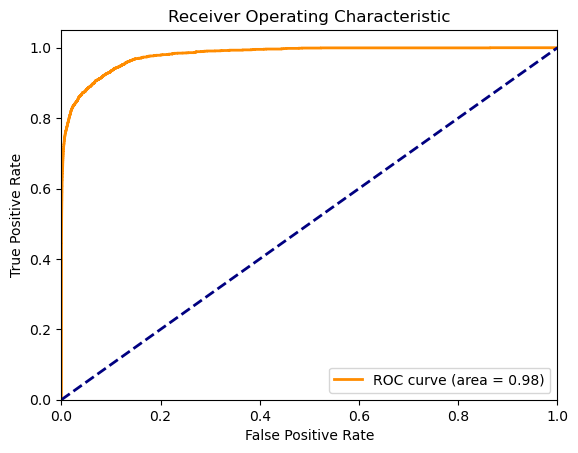

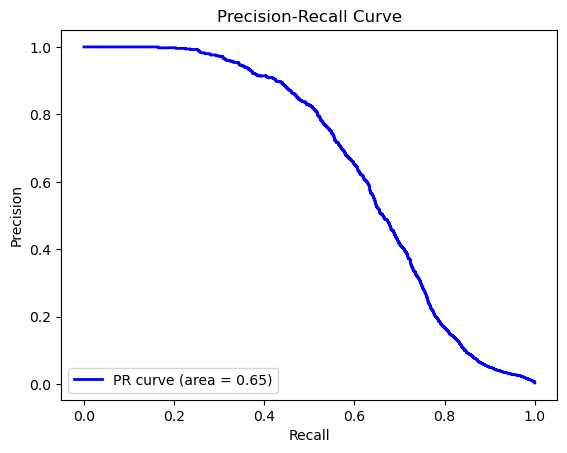

In [11]:
# Make predictions on the unseen data with the best estimator
y_unseen_pred = best_model.predict(X_unseen_scaled_df)
y_unseen_pred_proba = best_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Evaluate the model on the unseen data
print("Unseen Data Accuracy:", accuracy_score(y_unseen, y_unseen_pred))
print("Unseen Data Classification Report:\n", classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:\n", confusion_matrix(y_unseen, y_unseen_pred))
print("Unseen Data ROC AUC Score:", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score:", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

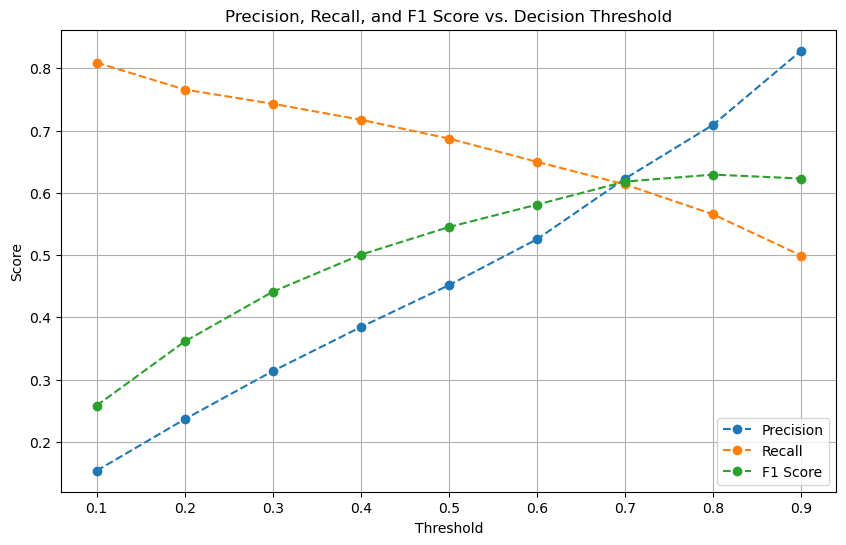

Best Threshold: 0.8
Unseen Data Accuracy (Tuned Threshold): 0.9974285565186722
Unseen Data Classification Report (Tuned Threshold):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.71      0.57      0.63      2145

    accuracy                           1.00    555719
   macro avg       0.85      0.78      0.81    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix (Tuned Threshold):
 [[553077    497]
 [   932   1213]]
Unseen Data ROC AUC Score (Tuned Threshold): 0.9797708365498761
Unseen Data PR AUC Score (Tuned Threshold): 0.6501301529926784


In [14]:
# Import necessary libraries
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
import numpy as np

# Make predictions on the unseen data with the best estimator
y_unseen_pred_proba = best_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Define a list of thresholds to evaluate
thresholds = [0.1, 0.2, 0.3, 0.4 , 0.5 , 0.6, 0.7, 0.8, 0.9]

# Initialize lists to store metrics
precision_list = []
recall_list = []
f1_list = []

# Evaluate metrics for each threshold
for threshold in thresholds:
    y_unseen_pred_threshold = (y_unseen_pred_proba >= threshold).astype(int)
    precision = precision_score(y_unseen, y_unseen_pred_threshold)
    recall = recall_score(y_unseen, y_unseen_pred_threshold)
    f1 = f1_score(y_unseen, y_unseen_pred_threshold)
    
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)

# Plot Precision, Recall, and F1 Score vs. Decision Threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision_list, label='Precision', linestyle='--', marker='o')
plt.plot(thresholds, recall_list, label='Recall', linestyle='--', marker='o')
plt.plot(thresholds, f1_list, label='F1 Score', linestyle='--', marker='o')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score vs. Decision Threshold')
plt.legend(loc='best')
plt.grid()
plt.show()

# Find the threshold that maximizes the F1 score
best_threshold = thresholds[np.argmax(f1_list)]
print("Best Threshold:", best_threshold)

# Apply the best threshold to the predictions
y_unseen_pred_tuned = (y_unseen_pred_proba >= best_threshold).astype(int)

# Evaluate the tuned threshold predictions
print("Unseen Data Accuracy (Tuned Threshold):", accuracy_score(y_unseen, y_unseen_pred_tuned))
print("Unseen Data Classification Report (Tuned Threshold):\n", classification_report(y_unseen, y_unseen_pred_tuned))
print("Unseen Data Confusion Matrix (Tuned Threshold):\n", confusion_matrix(y_unseen, y_unseen_pred_tuned))
print("Unseen Data ROC AUC Score (Tuned Threshold):", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score (Tuned Threshold):", average_precision_score(y_unseen, y_unseen_pred_proba))


Unseen Data Accuracy (Fixed Threshold): 0.9927337377343586
Unseen Data Classification Report (Fixed Threshold):
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.31      0.74      0.44      2145

    accuracy                           0.99    555719
   macro avg       0.66      0.87      0.72    555719
weighted avg       1.00      0.99      0.99    555719

Unseen Data Confusion Matrix (Fixed Threshold):
 [[550087   3487]
 [   551   1594]]
Unseen Data ROC AUC Score (Fixed Threshold): 0.9797708365498761
Unseen Data PR AUC Score (Fixed Threshold): 0.6501301529926784


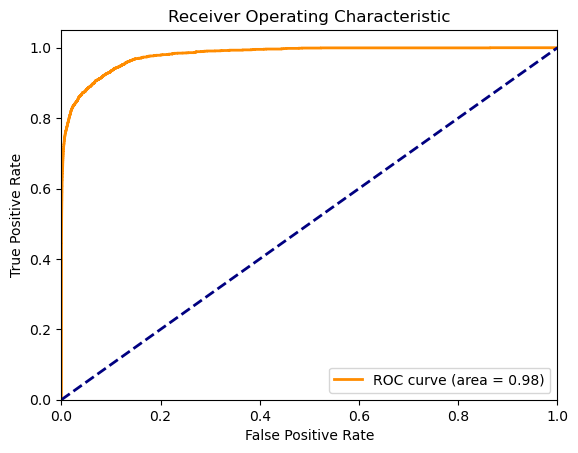

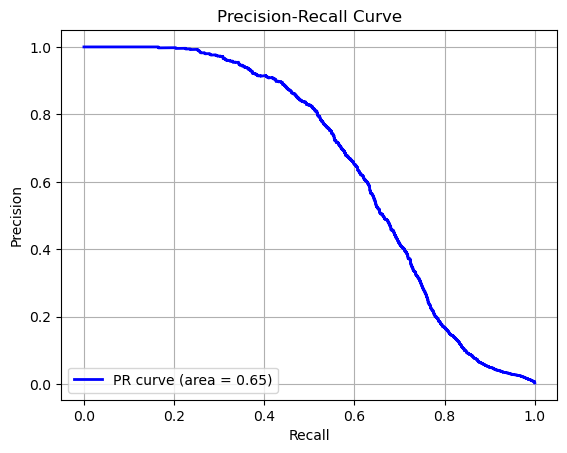

Chosen Fixed Threshold: 0.3


In [20]:
# Import necessary libraries
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Make predictions on the unseen data with the best estimator
y_unseen_pred_proba = best_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Define a fixed threshold
fixed_threshold = 0.3  # You can manually change this value

# Apply the fixed threshold to the predictions
y_unseen_pred_fixed = (y_unseen_pred_proba >= fixed_threshold).astype(int)

# Evaluate the model on the unseen data with the fixed threshold
print("Unseen Data Accuracy (Fixed Threshold):", accuracy_score(y_unseen, y_unseen_pred_fixed))
print("Unseen Data Classification Report (Fixed Threshold):\n", classification_report(y_unseen, y_unseen_pred_fixed))
print("Unseen Data Confusion Matrix (Fixed Threshold):\n", confusion_matrix(y_unseen, y_unseen_pred_fixed))
print("Unseen Data ROC AUC Score (Fixed Threshold):", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score (Fixed Threshold):", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid()
plt.show()

# Print the chosen threshold for reference
print("Chosen Fixed Threshold:", fixed_threshold)